In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#FAFAFA",
    "axes.facecolor":   "#FFFFFF",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size": 11,
})

In [6]:
np.random.seed(2026)
N = 1_200

PRODUK   = ["Laptop ProX", "Smartphone Z9", "Tablet Air", "Monitor 4K",
            "Mouse Wireless", "Keyboard Mech", "Headset Pro", "Webcam HD"]
KATEGORI = ["Komputer", "Smartphone", "Tablet", "Komputer",
            "Aksesori", "Aksesori", "Aksesori", "Aksesori"]
HARGA    = {
    "Laptop ProX":    18_500_000, "Smartphone Z9": 8_200_000,
    "Tablet Air":      6_500_000, "Monitor 4K":    4_800_000,
    "Mouse Wireless":    350_000, "Keyboard Mech":   580_000,
    "Headset Pro":     1_200_000, "Webcam HD":        750_000,
}
KOTA   = ["Jakarta", "Surabaya", "Bandung", "Medan",
          "Makassar", "Semarang", "Palembang", "Yogyakarta"]
SALES  = ["Andi Pratama", "Siti Rahma", "Budi Santoso",
          "Dewi Lestari", "Reza Firmansyah"]
CHANNEL = ["Online", "Offline", "Reseller"]

start   = datetime(2026, 1, 1)
tanggal = [start + timedelta(days=int(d)) for d in np.random.randint(0, 90, N)]
idx     = np.random.randint(0, len(PRODUK), N)

df = pd.DataFrame({
    "tanggal"     : tanggal,
    "produk"      : [PRODUK[i] for i in idx],
    "kategori"    : [KATEGORI[i] for i in idx],
    "kota"        : np.random.choice(KOTA, N),
    "sales_person": np.random.choice(SALES, N),
    "channel"     : np.random.choice(CHANNEL, N, p=[0.5, 0.3, 0.2]),
    "qty"         : np.random.randint(1, 8, N),
    "diskon_pct"  : np.random.choice([0,5,10,15,20], N, p=[0.35,0.25,0.2,0.12,0.08]),
    "retur"       : np.random.choice([0,1], N, p=[0.93, 0.07]),
})

df["harga_satuan"]   = df["produk"].map(HARGA)
df["revenue"]        = df["qty"] * df["harga_satuan"] * (1 - df["diskon_pct"] / 100)
df["revenue_bersih"] = df["revenue"] * (1 - df["retur"])
df["cogs"]           = df["revenue_bersih"] * np.random.uniform(0.55, 0.70, N)
df["profit"]         = df["revenue_bersih"] - df["cogs"]
df["margin_pct"]     = (df["profit"] / df["revenue_bersih"].replace(0, np.nan) * 100).fillna(0)
df["bulan"]          = df["tanggal"].dt.to_period("M")
df["bulan_nama"]     = df["tanggal"].dt.strftime("%b %Y")
df["minggu"]         = df["tanggal"].dt.isocalendar().week.astype(int)
df["hari_nama"]      = df["tanggal"].dt.day_name()

print(f"Data : {len(df):,} baris")
print(f"Periode: {df['tanggal'].min().date()} s/d {df['tanggal'].max().date()}")
df.head()

Data : 1,200 baris
Periode: 2026-01-01 s/d 2026-03-31


,tanggal,produk,kategori,kota,sales_person,channel,qty,diskon_pct,retur,harga_satuan,revenue,revenue_bersih,cogs,profit,margin_pct,bulan,bulan_nama,minggu,hari_nama
0,2026-01-02,Mouse Wireless,Aksesori,Semarang,Budi Santoso,Reseller,2,5,0,350000,665000.0,665000.0,3.885780e+05,2.764220e+05,41.567216,2026-01,Jan 2026,1,Friday
1,2026-01-07,Tablet Air,Tablet,Palembang,Reza Firmansyah,Online,1,5,0,6500000,6175000.0,6175000.0,3.931785e+06,2.243215e+06,36.327362,2026-01,Jan 2026,2,Wednesday
2,2026-01-27,Smartphone Z9,Smartphone,Semarang,Reza Firmansyah,Offline,6,15,0,8200000,41820000.0,41820000.0,2.553540e+07,1.628460e+07,38.939745,2026-01,Jan 2026,5,Tuesday
3,2026-02-26,Smartphone Z9,Smartphone,Yogyakarta,Reza Firmansyah,Offline,4,0,0,8200000,32800000.0,32800000.0,2.048139e+07,1.231861e+07,37.556740,2026-02,Feb 2026,9,Thursday
4,2026-03-19,Webcam HD,Aksesori,Surabaya,Dewi Lestari,Offline,6,5,0,750000,4275000.0,4275000.0,2.711032e+06,1.563968e+06,36.584044,2026-03,Mar 2026,12,Thursday


In [7]:
total_revenue   = df["revenue_bersih"].sum()
total_profit    = df["profit"].sum()
total_transaksi = len(df)
aov             = df["revenue_bersih"].mean()
avg_margin      = df["margin_pct"].mean()
retur_rate      = df["retur"].mean() * 100

print("=" * 58)
print("        RINGKASAN KPI — Q1 2026 (Jan–Mar)")
print("=" * 58)
print(f"  Total Revenue Bersih  : Rp {total_revenue:>15,.0f}")
print(f"  Total Profit          : Rp {total_profit:>15,.0f}")
print(f"  Total Transaksi       :    {total_transaksi:>15,}")
print(f"  Avg Order Value (AOV) : Rp {aov:>15,.0f}")
print(f"  Avg Profit Margin     :    {avg_margin:>14.1f}%")
print(f"  Tingkat Retur         :    {retur_rate:>14.1f}%")
print("=" * 58)

kpi_bulan = df.groupby("bulan_nama").agg(
    Revenue   =("revenue_bersih", "sum"),
    Profit    =("profit", "sum"),
    Transaksi =("revenue_bersih", "count"),
    AOV       =("revenue_bersih", "mean"),
    Margin_pct=("margin_pct", "mean"),
).round(0)
kpi_bulan["Growth_%"] = kpi_bulan["Revenue"].pct_change().mul(100).round(1)

print("\nKPI per Bulan:")
print(kpi_bulan.to_string())

        RINGKASAN KPI — Q1 2026 (Jan–Mar)
  Total Revenue Bersih  : Rp  21,464,046,500
  Total Profit          : Rp   8,030,186,606
  Total Transaksi       :              1,200
  Avg Order Value (AOV) : Rp      17,886,705
  Avg Profit Margin     :              34.8%
  Tingkat Retur         :               7.2%

KPI per Bulan:
                 Revenue        Profit  Transaksi         AOV  Margin_pct  Growth_%
bulan_nama                                                                         
Feb 2026    6.715154e+09  2.508616e+09        367  18297422.0        35.0       NaN
Jan 2026    7.801956e+09  2.915554e+09        413  18890936.0        35.0      16.2
Mar 2026    6.946936e+09  2.606017e+09        420  16540324.0        34.0     -11.0


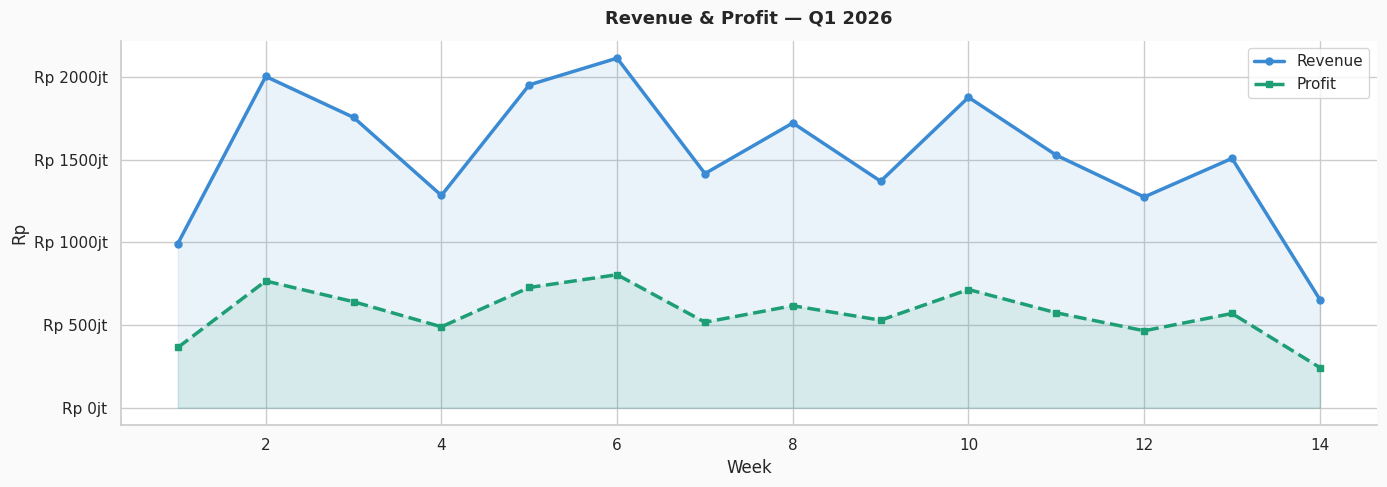

In [9]:
rev_minggu = df.groupby("minggu").agg(
    Revenue=("revenue_bersih", "sum"),
    Profit =("profit", "sum")
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rev_minggu["minggu"], rev_minggu["Revenue"] / 1e6,
        color="#3B8BD4", lw=2.5, marker="o", ms=5, label="Revenue")
ax.fill_between(rev_minggu["minggu"], rev_minggu["Revenue"] / 1e6,
                alpha=0.1, color="#3B8BD4")
ax.plot(rev_minggu["minggu"], rev_minggu["Profit"] / 1e6,
        color="#1D9E75", lw=2.5, marker="s", ms=5, linestyle="--", label="Profit")
ax.fill_between(rev_minggu["minggu"], rev_minggu["Profit"] / 1e6,
                alpha=0.1, color="#1D9E75")

ax.set_title("Revenue & Profit — Q1 2026", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Week")
ax.set_ylabel("Rp")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"Rp {x:.0f}jt"))
ax.legend()
plt.tight_layout()
plt.show()

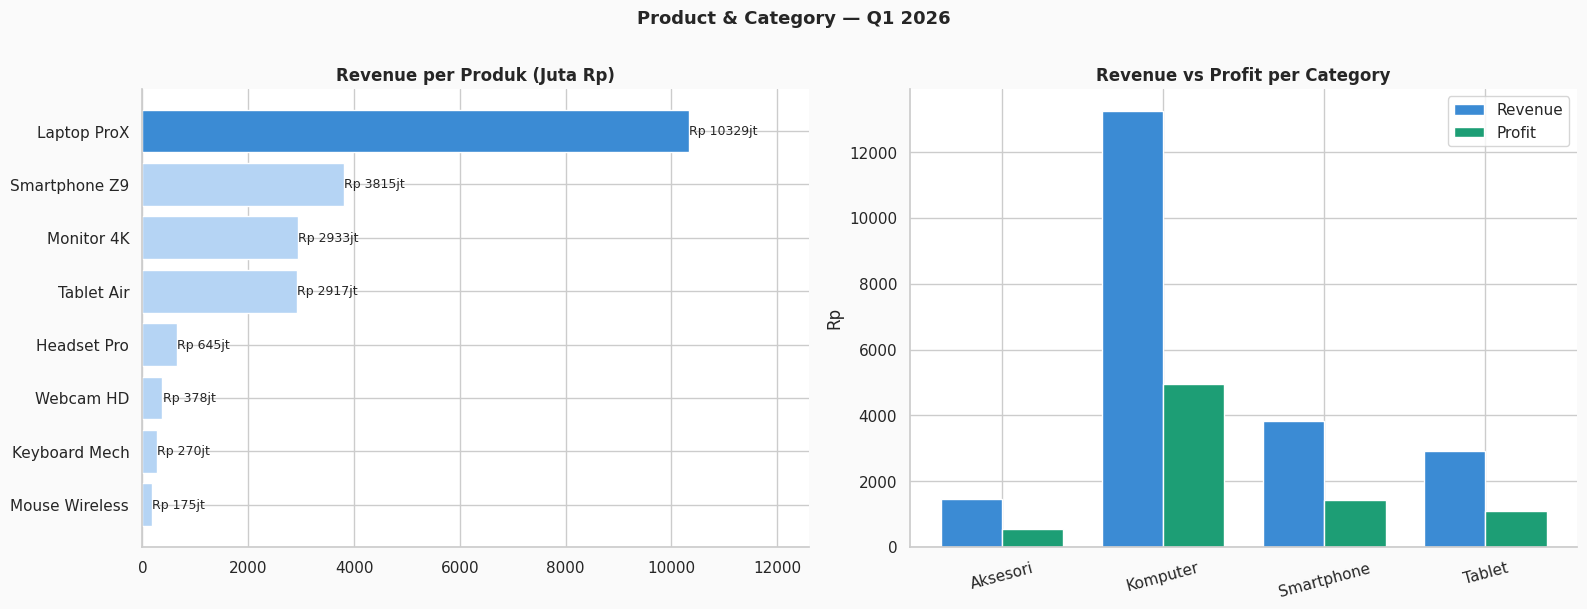

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar horizontal — revenue per produk
rev_produk = df.groupby("produk")["revenue_bersih"].sum().sort_values()
colors     = ["#3B8BD4" if v == rev_produk.max() else "#B5D4F4" for v in rev_produk]
axes[0].barh(rev_produk.index, rev_produk.values / 1e6, color=colors)
for i, v in enumerate(rev_produk.values):
    axes[0].text(v / 1e6 + 3, i, f"Rp {v/1e6:.0f}jt", va="center", fontsize=9)
axes[0].set_title("Revenue per Produk (Juta Rp)", fontweight="bold")
axes[0].set_xlim(0, rev_produk.max() / 1e6 * 1.22)

# Grouped bar — revenue vs profit per kategori
kpi_kat = df.groupby("kategori").agg(
    Revenue=("revenue_bersih", "sum"),
    Profit =("profit", "sum")
).reset_index()
x = np.arange(len(kpi_kat))
w = 0.38
axes[1].bar(x - w/2, kpi_kat["Revenue"] / 1e6, w, label="Revenue", color="#3B8BD4")
axes[1].bar(x + w/2, kpi_kat["Profit"]  / 1e6, w, label="Profit",  color="#1D9E75")
axes[1].set_xticks(x)
axes[1].set_xticklabels(kpi_kat["kategori"], rotation=15)
axes[1].set_title("Revenue vs Profit per Category", fontweight="bold")
axes[1].set_ylabel("Rp")
axes[1].legend()

plt.suptitle("Product & Category — Q1 2026", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [14]:
rev_harian = df.groupby("tanggal").agg(
    Revenue  =("revenue_bersih", "sum"),
    Transaksi=("revenue_bersih", "count")
).reset_index()
rev_harian["MA7"] = rev_harian["Revenue"].rolling(7).mean()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Daily Revenue & Moving Average 7 Days",
        "Revenue per Product",
        "Revenue per City",
        "Avg Margin Profit per Sales Person"
    )
)

# Panel 1 — revenue harian + MA7
fig.add_trace(go.Scatter(
    x=rev_harian["tanggal"], y=rev_harian["Revenue"] / 1e6,
    mode="lines", name="Revenue", line=dict(color="#B5D4F4", width=1.5)
), row=1, col=1)
fig.add_trace(go.Scatter(
    x=rev_harian["tanggal"], y=rev_harian["MA7"] / 1e6,
    mode="lines", name="MA-7", line=dict(color="#185FA5", width=2.5)
), row=1, col=1)

# Panel 2 — bar produk
rev_prod = df.groupby("produk")["revenue_bersih"].sum().sort_values(ascending=False).reset_index()
fig.add_trace(go.Bar(
    x=rev_prod["produk"], y=rev_prod["revenue_bersih"] / 1e6,
    marker_color="#3B8BD4", name="Produk", showlegend=False
), row=1, col=2)

# Panel 3 — bar kota
rev_kota = df.groupby("kota")["revenue_bersih"].sum().sort_values(ascending=False).reset_index()
fig.add_trace(go.Bar(
    x=rev_kota["kota"], y=rev_kota["revenue_bersih"] / 1e6,
    marker_color="#1D9E75", name="Kota", showlegend=False
), row=2, col=1)

# Panel 4 — margin per sales
margin_sales = df.groupby("sales_person")["margin_pct"].mean().sort_values(ascending=False).reset_index()
fig.add_trace(go.Bar(
    x=margin_sales["sales_person"], y=margin_sales["margin_pct"].round(1),
    marker_color="#BA7517", name="Margin", showlegend=False,
    text=margin_sales["margin_pct"].round(1).astype(str) + "%",
    textposition="outside"
), row=2, col=2)

fig.update_layout(
    height=650,
    title_text="Interactive Sales Dashboard — Q1 2026",
    title_font_size=15,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(ticksuffix="jt", row=1, col=1)
fig.update_yaxes(ticksuffix="jt", row=1, col=2)
fig.update_yaxes(ticksuffix="jt", row=2, col=1)
fig.update_yaxes(ticksuffix="%",  row=2, col=2)

fig.show()

In [19]:
print("=" * 60)
print("      BUSINESS INSIGHT OTOMATIS — Q1 2026")
print("=" * 60)

top_produk = df.groupby("produk")["revenue_bersih"].sum()
print(f"\n Produk terlaris   : {top_produk.idxmax()} (Rp {top_produk.max()/1e6:.0f} juta)")


top_sales = df.groupby("sales_person")["revenue_bersih"].sum()
print(f" Sales terbaik     : {top_sales.idxmax()} (Rp {top_sales.max()/1e6:.0f} juta)")

top_ch = df.groupby("channel")["revenue_bersih"].sum()
print(f" Channel terbaik   : {top_ch.idxmax()} ({top_ch.max()/top_ch.sum()*100:.1f}% dari total)")

top_hari = df.groupby("hari_nama")["revenue_bersih"].sum()
print(f" Hari tersibuk     : {top_hari.idxmax()}")

top_cat = df.groupby("kategori")["margin_pct"].mean()
print(f" Margin tertinggi  : kategori {top_cat.idxmax()} ({top_cat.max():.1f}%)")

rev_bulan = df.groupby("bulan_nama")["revenue_bersih"].sum()
bulan_list = list(rev_bulan.items())
for i in range(1, len(bulan_list)):
    nama_lalu, val_lalu = bulan_list[i-1]
    nama_ini,  val_ini  = bulan_list[i]
    growth = (val_ini / val_lalu - 1) * 100
    arah   = "naik" if growth > 0 else "turun"
    print(f" Growth {nama_lalu[:3]}→{nama_ini[:3]}     : {growth:+.1f}% ({arah})")

print(f"\n Retur rate        : {df['retur'].mean()*100:.1f}% ({df['retur'].sum()} transaksi)")
print(f" Diskon rata-rata  : {df['diskon_pct'].mean():.1f}%")
print(f" Produk low margin : {df.groupby('produk')['margin_pct'].mean().idxmin()}")
print("=" * 60)
print("\n Analisis Q1 2026 selesai!")

      BUSINESS INSIGHT OTOMATIS — Q1 2026

 Produk terlaris   : Laptop ProX (Rp 10329 juta)
 Sales terbaik     : Reza Firmansyah (Rp 5174 juta)
 Channel terbaik   : Online (49.9% dari total)
 Hari tersibuk     : Tuesday
 Margin tertinggi  : kategori Tablet (36.1%)
 Growth Feb→Jan     : +16.2% (naik)
 Growth Jan→Mar     : -11.0% (turun)

 Retur rate        : 7.2% (87 transaksi)
 Diskon rata-rata  : 6.5%
 Produk low margin : Headset Pro

 Analisis Q1 2026 selesai!
